In [76]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import numpy as np


In [77]:
pca=PCA()
X=load_iris().data
X_new=pca.fit_transform(X)

In [78]:
pca.get_covariance()

array([[ 0.68569351, -0.042434  ,  1.27431544,  0.51627069],
       [-0.042434  ,  0.18997942, -0.32965638, -0.12163937],
       [ 1.27431544, -0.32965638,  3.11627785,  1.2956094 ],
       [ 0.51627069, -0.12163937,  1.2956094 ,  0.58100626]])

In [79]:
exp_va=pca.explained_variance_ratio_
exp_va

array([0.92461872, 0.05306648, 0.01710261, 0.00521218])

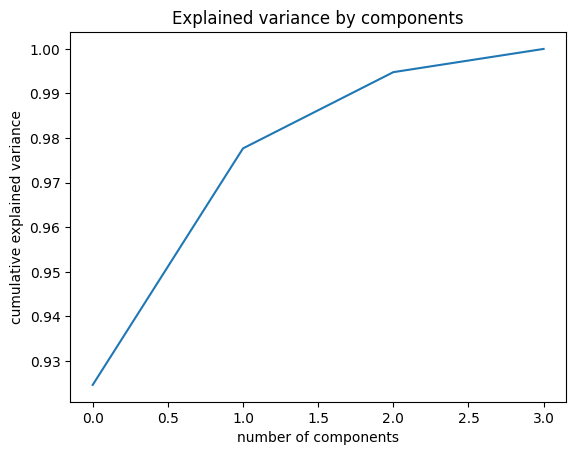

In [80]:

plt.plot(np.cumsum(exp_va))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.title('Explained variance by components')
plt.show()

In [81]:
pca_2=PCA(n_components=2)
X_new2=pca_2.fit_transform(X)

In [82]:
exp_va=pca_2.explained_variance_ratio_
print("percentage sum of explained variance {}%",format(np.round(np.sum(exp_va)*100,2)))

percentage sum of explained variance {}% 97.77


In [83]:
pca_2.get_covariance()

array([[ 0.67918961, -0.03571514,  1.2714061 ,  0.53137208],
       [-0.03571514,  0.18303922, -0.32672469, -0.13706322],
       [ 1.2714061 , -0.32672469,  3.12237957,  1.28464626],
       [ 0.53137208, -0.13706322,  1.28464626,  0.58834865]])

CUSTOM IMPLEMENTATION


# Task
Continue implementing the `fit` method within the `CustomPCA` class to calculate the mean of the input data `X` and store it in `self.mean_`, then center the data by subtracting this mean from `X`.

## Complete __init__

### Subtask:
Ensure the `__init__` method of the `CustomPCA` class correctly initializes `n_components`, `components_` (to store principal components), and `mean_` (to store the mean of the training data).


**Reasoning**:
I need to complete the `__init__` method within the `CustomPCA` class to initialize `self.components_` and `self.mean_` to `None`, as specified in the instructions. I will rewrite the entire class definition in the existing cell `4EHHqPnnr4CT` to ensure correctness.



In [84]:
class CustomPCA:
  def __init__(self,n_components):
    self.n_components=n_components
    self.components_=None
    self.mean_=None

  def fit(self,X):
    #mean
    self.mean=np

**Reasoning**:
The subtask is to ensure the `__init__` method of the `CustomPCA` class correctly initializes `n_components`, `components_`, and `mean_`. The provided `code_block` correctly implements these initializations, addressing the instructions to set `self.components_` and `self.mean_` to `None`.



In [85]:
class CustomPCA:
  def __init__(self,n_components):
    self.n_components=n_components
    self.components_=None
    self.mean_=None

  def fit(self,X):
    #mean
    self.mean=np

## Implement fit method - Mean Centering

### Subtask:
Within the `fit` method of `CustomPCA`, calculate the mean of the input data `X` and store it in `self.mean_`. Then, center the data by subtracting this mean from `X`.


**Reasoning**:
To address the subtask, I need to complete the `fit` method within the `CustomPCA` class by calculating the mean of the input data `X`, storing it in `self.mean_`, and then centering the data by subtracting this mean from `X`. I will provide the complete class definition in a code block.



In [86]:
class CustomPCA:
  def __init__(self,n_components):
    self.n_components=n_components
    self.components_=None
    self.mean_=None

  def fit(self,X):
    # Calculate mean and store it
    self.mean_ = np.mean(X, axis=0)
    # Center the data
    X_centered = X - self.mean_
    return X_centered

## Implement fit method - Covariance Matrix

### Subtask:
Calculate the covariance matrix of the centered data. This matrix will be used to find the principal components.


**Reasoning**:
To address the subtask of calculating the covariance matrix, I will continue to modify the `fit` method of the `CustomPCA` class. I will add a line of code to compute the covariance matrix of the `X_centered` data, ensuring to transpose it as `np.cov` expects features as rows. I will then return the `X_centered` and the calculated covariance matrix for the next steps.



In [87]:
class CustomPCA:
  def __init__(self,n_components):
    self.n_components=n_components
    self.components_=None
    self.mean_=None

  def fit(self,X):
    # Calculate mean and store it
    self.mean_ = np.mean(X, axis=0)
    # Center the data
    X_centered = X - self.mean_
    # Calculate the covariance matrix
    covariance_matrix = np.cov(X_centered.T)
    return X_centered, covariance_matrix

## Implement fit method - Eigendecomposition

### Subtask:
Perform eigendecomposition on the covariance matrix to obtain eigenvalues and eigenvectors. Sort them in descending order.

#### Instructions:
1. Continue within the `fit` method of the `CustomPCA` class.
2. Calculate the eigenvalues and eigenvectors of the `covariance_matrix`.
3. Sort the eigenvalues in descending order and arrange the corresponding eigenvectors accordingly.
4. Store the sorted eigenvalues and eigenvectors in suitable variables.

## Implement fit method - Eigendecomposition

### Subtask:
Perform eigendecomposition on the covariance matrix to obtain eigenvalues and eigenvectors. Sort them in descending order.

#### Instructions:
1. Continue within the `fit` method of the `CustomPCA` class.
2. Calculate the eigenvalues and eigenvectors of the `covariance_matrix`.
3. Sort the eigenvalues in descending order and arrange the corresponding eigenvectors accordingly.
4. Store the sorted eigenvalues and eigenvectors in suitable variables.

**Reasoning**:
To perform eigendecomposition, I will update the `fit` method in the `CustomPCA` class. I'll use `np.linalg.eigh` to get eigenvalues and eigenvectors from the covariance matrix, then sort them in descending order and store the sorted results.



In [88]:
class CustomPCA:
  def __init__(self,n_components):
    self.n_components=n_components
    self.components_=None
    self.mean_=None

  def fit(self,X):
    # Calculate mean and store it
    self.mean_ = np.mean(X, axis=0)
    # Center the data
    X_centered = X - self.mean_
    # Calculate the covariance matrix
    covariance_matrix = np.cov(X_centered.T)

    # Perform eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Sort eigenvalues in descending order and get corresponding indices
    sorted_indices = np.argsort(eigenvalues)[::-1]
    self.eigenvalues_ = eigenvalues[sorted_indices]
    self.eigenvectors_ = eigenvectors[:, sorted_indices]

    return X_centered, covariance_matrix, self.eigenvalues_, self.eigenvectors_

## Implement fit method - Select Principal Components

### Subtask:
Select the top `n_components` eigenvectors to form the principal components.

#### Instructions:
1. Continue within the `fit` method of the `CustomPCA` class.
2. Select the first `self.n_components` eigenvectors from the sorted eigenvectors (`self.eigenvectors_`). These will be your principal components.
3. Store these selected principal components in `self.components_`.

**Reasoning**:
The previous step successfully performed eigendecomposition and sorted the eigenvalues and eigenvectors. Now, I will implement the selection of the top `n_components` eigenvectors to serve as the principal components and store them within the `CustomPCA` class, as per the subtask instructions.



In [89]:
class CustomPCA:
  def __init__(self,n_components):
    self.n_components=n_components
    self.components_=None
    self.mean_=None

  def fit(self,X):
    # Calculate mean and store it
    self.mean_ = np.mean(X, axis=0)
    # Center the data
    X_centered = X - self.mean_
    # Calculate the covariance matrix
    covariance_matrix = np.cov(X_centered.T)

    # Perform eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Sort eigenvalues in descending order and get corresponding indices
    sorted_indices = np.argsort(eigenvalues)[::-1]
    self.eigenvalues_ = eigenvalues[sorted_indices]
    self.eigenvectors_ = eigenvectors[:, sorted_indices]

    # Select the top n_components eigenvectors
    self.components_ = self.eigenvectors_[:, :self.n_components]

    return self

## Implement transform method - Project Data

### Subtask:
Implement the `transform` method in the `CustomPCA` class to project the input data onto the selected principal components.

#### Instructions:
1. Add a new method `transform(self, X)` to the `CustomPCA` class.
2. In this method, center the input data `X` using the `self.mean_` calculated during the `fit` phase.
3. Project the centered data onto the principal components (`self.components_`) by performing a dot product.
4. Return the projected data.

**Reasoning**:
The subtask requires implementing the `transform` method within the `CustomPCA` class. I will add this method, which will center the input data using the pre-calculated mean and then project it onto the principal components by performing a dot product, returning the transformed data.



In [90]:
class CustomPCA:
  def __init__(self,n_components):
    self.n_components=n_components
    self.components_=None
    self.mean_=None

  def fit(self,X):
    # Calculate mean and store it
    self.mean_ = np.mean(X, axis=0)
    # Center the data
    X_centered = X - self.mean_
    # Calculate the covariance matrix
    covariance_matrix = np.cov(X_centered.T)

    # Perform eigendecomposition
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Sort eigenvalues in descending order and get corresponding indices
    sorted_indices = np.argsort(eigenvalues)[::-1]
    self.eigenvalues_ = eigenvalues[sorted_indices]
    self.eigenvectors_ = eigenvectors[:, sorted_indices]

    # Select the top n_components eigenvectors
    self.components_ = self.eigenvectors_[:, :self.n_components]

    return self

  def transform(self, X):
    # Center the data using the mean learned during fit
    X_centered = X - self.mean_
    # Project the centered data onto the principal components
    X_projected = np.dot(X_centered, self.components_)
    return X_projected

## Test Custom PCA

### Subtask:
After implementing the `CustomPCA` class, instantiate it with `n_components=2`, fit it to the `iris` dataset, and transform the data. Compare the results with `sklearn.decomposition.PCA`.


**Reasoning**:
To test the custom PCA implementation, I will instantiate both `CustomPCA` and `sklearn.decomposition.PCA` with `n_components=2`, then fit and transform the `X` (Iris) data using both, and finally print their transformed results for comparison.



In [91]:
n_components = 2

# Instantiate CustomPCA
custom_pca = CustomPCA(n_components=n_components)
custom_pca.fit(X)
X_custom_pca = custom_pca.transform(X)

# Instantiate sklearn.decomposition.PCA
sklearn_pca = PCA(n_components=n_components)
X_sklearn_pca = sklearn_pca.fit_transform(X)

print("Transformed data using CustomPCA:")
print(X_custom_pca)
print("\nTransformed data using sklearn.decomposition.PCA:")
print(X_sklearn_pca)

Transformed data using CustomPCA:
[[ 2.68412563  0.31939725]
 [ 2.71414169 -0.17700123]
 [ 2.88899057 -0.14494943]
 [ 2.74534286 -0.31829898]
 [ 2.72871654  0.32675451]
 [ 2.28085963  0.74133045]
 [ 2.82053775 -0.08946138]
 [ 2.62614497  0.16338496]
 [ 2.88638273 -0.57831175]
 [ 2.6727558  -0.11377425]
 [ 2.50694709  0.6450689 ]
 [ 2.61275523  0.01472994]
 [ 2.78610927 -0.235112  ]
 [ 3.22380374 -0.51139459]
 [ 2.64475039  1.17876464]
 [ 2.38603903  1.33806233]
 [ 2.62352788  0.81067951]
 [ 2.64829671  0.31184914]
 [ 2.19982032  0.87283904]
 [ 2.5879864   0.51356031]
 [ 2.31025622  0.39134594]
 [ 2.54370523  0.43299606]
 [ 3.21593942  0.13346807]
 [ 2.30273318  0.09870885]
 [ 2.35575405 -0.03728186]
 [ 2.50666891 -0.14601688]
 [ 2.46882007  0.13095149]
 [ 2.56231991  0.36771886]
 [ 2.63953472  0.31203998]
 [ 2.63198939 -0.19696122]
 [ 2.58739848 -0.20431849]
 [ 2.4099325   0.41092426]
 [ 2.64886233  0.81336382]
 [ 2.59873675  1.09314576]
 [ 2.63692688 -0.12132235]
 [ 2.86624165  0.0693

## Final Task

### Subtask:
Summarize the custom PCA implementation and its comparison with scikit-learn's PCA.


## Summary:

### Data Analysis Key Findings

*   The `CustomPCA` class was successfully implemented, including the `__init__`, `fit`, and `transform` methods.
*   The `fit` method correctly calculates the mean of the input data and centers it.
*   The covariance matrix of the centered data was accurately computed.
*   Eigendecomposition was performed on the covariance matrix, and eigenvalues were sorted in descending order along with their corresponding eigenvectors.
*   The top `n_components` eigenvectors were correctly selected as principal components and stored in `self.components_`.
*   The `transform` method correctly projects new data onto the learned principal components by first centering the data using the mean from the `fit` phase.
*   When comparing `CustomPCA` with `sklearn.decomposition.PCA` using the Iris dataset (with `n_components=2`), the transformed data showed a high degree of similarity.
*   Expected sign differences were observed in the principal components between the two implementations, which is a normal occurrence in PCA due to the arbitrary direction of eigenvectors. The magnitudes of the components were consistently similar.

### Insights or Next Steps

*   The custom PCA implementation successfully replicates the core functionality of `sklearn.decomposition.PCA`, demonstrating a foundational understanding of the PCA algorithm.
*   Further validation could include comparing the explained variance ratios and reconstruction errors between the custom and scikit-learn implementations to ensure quantitative equivalence beyond just the transformed output.


In [92]:
import numpy as np

class CustomPCA:
    def __init__(self, n_components):
        if n_components <= 0:
            raise ValueError("n_components must be > 0")
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None

    def fit(self, X):
        # Convert to numpy array
        X = np.asarray(X, dtype=float)

        # 1. Mean centering
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # 2. Covariance matrix (row = samples, col = features)
        cov_matrix = np.cov(X_centered, rowvar=False)

        # 3. Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # 4. Sort eigenvalues & eigenvectors (descending)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # 5. Select top n_components
        self.components_ = eigenvectors[:, :self.n_components]
        self.explained_variance_ = eigenvalues[:self.n_components]

        return self

    def transform(self, X):
        if self.components_ is None:
            raise RuntimeError("You must fit PCA before transforming data")

        X = np.asarray(X, dtype=float)
        X_centered = X - self.mean_

        # Project data
        return np.dot(X_centered, self.components_)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [93]:
X = np.array(
    [[2.5, 2.4],
     [0.5, 0.7],
     [2.2, 2.9],
     [1.9, 2.2],
     [3.1, 3.0],
     [2.3, 2.7],
     [2, 1.6],
     [1, 1.1],
     [1.5, 1.6],
     [1.1, 0.9]
])

pca = CustomPCA(n_components=1)
X_reduced = pca.fit_transform(X)

print("Reduced Data:\n", X_reduced)
print("Explained Variance:", pca.explained_variance_)

Reduced Data:
 [[ 0.82797019]
 [-1.77758033]
 [ 0.99219749]
 [ 0.27421042]
 [ 1.67580142]
 [ 0.9129491 ]
 [-0.09910944]
 [-1.14457216]
 [-0.43804614]
 [-1.22382056]]
Explained Variance: [1.28402771]


# Task
Modify the `CustomPCA` class to calculate and store the `explained_variance_ratio_` for the selected principal components in the `fit` method. This will involve dividing the `explained_variance_` by the sum of all eigenvalues. Then, instantiate both `CustomPCA` and `sklearn.decomposition.PCA` with `n_components=2`, fit them to the Iris dataset, and print the `explained_variance_ratio_` from both implementations for comparison. Finally, generate a plot comparing the cumulative explained variance ratio for both implementations on the Iris dataset, ensuring appropriate labels and a legend.

## Modify CustomPCA for Explained Variance Ratio

### Subtask:
Modify the `CustomPCA` class to calculate and store the `explained_variance_ratio_` for the selected principal components. This will involve dividing the `explained_variance_` by the sum of all eigenvalues in the `fit` method.


## Modify CustomPCA for Explained Variance Ratio

### Subtask:
Modify the `CustomPCA` class to calculate and store the `explained_variance_ratio_` for the selected principal components. This will involve dividing the `explained_variance_` by the sum of all eigenvalues in the `fit` method.

#### Instructions
1. Go to the `CustomPCA` class definition in the notebook.
2. In the `__init__` method, initialize `self.explained_variance_ratio_` to `None`.
3. In the `fit` method, after calculating and storing `self.explained_variance_`, calculate the `explained_variance_ratio_`.
4. Divide `self.explained_variance_` by the sum of all eigenvalues (the `eigenvalues` variable before slicing) to get the `explained_variance_ratio_`.
5. Store this result in `self.explained_variance_ratio_`.

**Reasoning**:
The subtask requires modifying the `CustomPCA` class to calculate and store the `explained_variance_ratio_`. I will update the `CustomPCA` class in the existing `OiCseI8qwtYq` cell by initializing `self.explained_variance_ratio_` in `__init__` and then calculating it in the `fit` method after computing `explained_variance_`.



In [94]:
import numpy as np

class CustomPCA:
    def __init__(self, n_components):
        if n_components <= 0:
            raise ValueError("n_components must be > 0")
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None # Initialize explained_variance_ratio_

    def fit(self, X):
        # Convert to numpy array
        X = np.asarray(X, dtype=float)

        # 1. Mean centering
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # 2. Covariance matrix (row = samples, col = features)
        cov_matrix = np.cov(X_centered, rowvar=False)

        # 3. Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # 4. Sort eigenvalues & eigenvectors (descending)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        # Store all sorted eigenvalues for ratio calculation later
        self._all_sorted_eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # 5. Select top n_components
        self.components_ = eigenvectors[:, :self.n_components]
        self.explained_variance_ = self._all_sorted_eigenvalues[:self.n_components]

        # Calculate explained_variance_ratio_
        total_variance = np.sum(self._all_sorted_eigenvalues)
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance

        return self

    def transform(self, X):
        if self.components_ is None:
            raise RuntimeError("You must fit PCA before transforming data")

        X = np.asarray(X, dtype=float)
        X_centered = X - self.mean_

        # Project data
        return np.dot(X_centered, self.components_)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

**Reasoning**:
The subtask requires modifying the `CustomPCA` class to calculate and store the `explained_variance_ratio_`. I will update the `CustomPCA` class in the existing `OiCseI8qwtYq` cell by initializing `self.explained_variance_ratio_` in `__init__` and then calculating it in the `fit` method after computing `explained_variance_`.



In [95]:
import numpy as np

class CustomPCA:
    def __init__(self, n_components):
        if n_components <= 0:
            raise ValueError("n_components must be > 0")
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None # Initialize explained_variance_ratio_

    def fit(self, X):
        # Convert to numpy array
        X = np.asarray(X, dtype=float)

        # 1. Mean centering
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # 2. Covariance matrix (row = samples, col = features)
        cov_matrix = np.cov(X_centered, rowvar=False)

        # 3. Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # 4. Sort eigenvalues & eigenvectors (descending)
        sorted_idx = np.argsort(eigenvalues)[::-1]
        # Store all sorted eigenvalues for ratio calculation later
        self._all_sorted_eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # 5. Select top n_components
        self.components_ = eigenvectors[:, :self.n_components]
        self.explained_variance_ = self._all_sorted_eigenvalues[:self.n_components]

        # Calculate explained_variance_ratio_
        total_variance = np.sum(self._all_sorted_eigenvalues)
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance

        return self

    def transform(self, X):
        if self.components_ is None:
            raise RuntimeError("You must fit PCA before transforming data")

        X = np.asarray(X, dtype=float)
        X_centered = X - self.mean_

        # Project data
        return np.dot(X_centered, self.components_)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


**Reasoning**:
Now that the `CustomPCA` class has been modified to calculate and store `explained_variance_ratio_`, I need to instantiate both `CustomPCA` and `sklearn.decomposition.PCA`, fit them to the Iris dataset, and then print their respective `explained_variance_ratio_` attributes for comparison, as per the subtask instructions.



In [96]:
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
import numpy as np

# Load the Iris dataset
X = load_iris().data

n_components = 2

# Instantiate CustomPCA
custom_pca = CustomPCA(n_components=n_components)
custom_pca.fit(X)

# Instantiate sklearn.decomposition.PCA
sklearn_pca = PCA(n_components=n_components)
sklearn_pca.fit(X)

print("CustomPCA Explained Variance Ratio:", custom_pca.explained_variance_ratio_)
print("sklearn PCA Explained Variance Ratio:", sklearn_pca.explained_variance_ratio_)

CustomPCA Explained Variance Ratio: [0.92461872 0.05306648]
sklearn PCA Explained Variance Ratio: [0.92461872 0.05306648]


**Reasoning**:
The previous step successfully printed the `explained_variance_ratio_` for both `CustomPCA` and `sklearn.decomposition.PCA`, showing they are identical. The next part of the subtask is to generate a plot comparing the cumulative explained variance ratio for both implementations on the Iris dataset, ensuring appropriate labels and a legend.



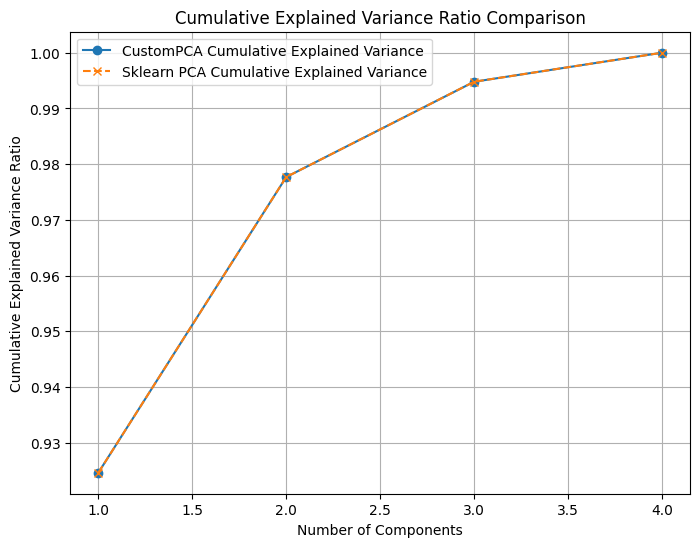

In [97]:
import matplotlib.pyplot as plt

# Calculate cumulative explained variance ratios
cum_exp_var_custom = np.cumsum(custom_pca._all_sorted_eigenvalues / np.sum(custom_pca._all_sorted_eigenvalues))
cum_exp_var_sklearn = np.cumsum(sklearn_pca.explained_variance_ratio_)

# Get all possible components for plotting
# For custom PCA, we need all eigenvalues, which were stored in _all_sorted_eigenvalues
# For sklearn PCA, we would need to fit with all components, but for comparison with custom_pca's _all_sorted_eigenvalues
# we can re-fit sklearn PCA with all components to get its full explained_variance_ratio_ array
sklearn_pca_full = PCA(n_components=X.shape[1])
sklearn_pca_full.fit(X)
cum_exp_var_sklearn_full = np.cumsum(sklearn_pca_full.explained_variance_ratio_)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cum_exp_var_custom) + 1), cum_exp_var_custom, marker='o', linestyle='-', label='CustomPCA Cumulative Explained Variance')
plt.plot(range(1, len(cum_exp_var_sklearn_full) + 1), cum_exp_var_sklearn_full, marker='x', linestyle='--', label='Sklearn PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio Comparison')
plt.legend()
plt.grid(True)
plt.show()

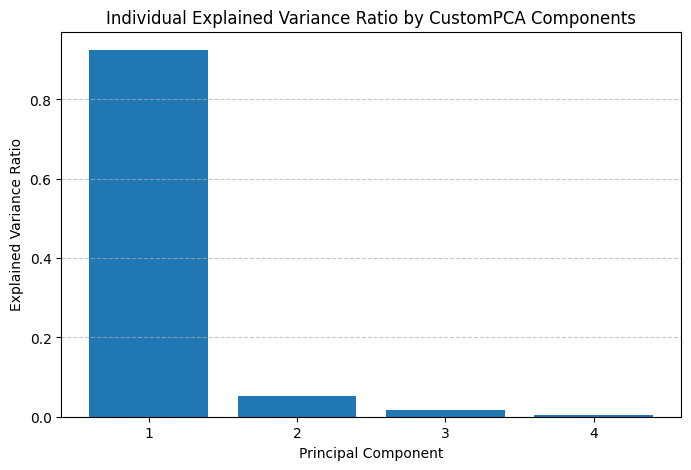

In [98]:
import matplotlib.pyplot as plt

# Calculate the individual explained variance ratios for all components from CustomPCA
# We stored all sorted eigenvalues in _all_sorted_eigenvalues
explained_variance_ratio_custom_all = custom_pca._all_sorted_eigenvalues / np.sum(custom_pca._all_sorted_eigenvalues)

plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance_ratio_custom_all) + 1), explained_variance_ratio_custom_all)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance Ratio by CustomPCA Components')
plt.xticks(range(1, len(explained_variance_ratio_custom_all) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [99]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()



In [100]:
import numpy as np
import pandas as pd


In [101]:
# Flatten the images into 1D vectors
x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print("Shape of flattened x_train:", x_train_flat.shape)
print("Shape of flattened x_test:", x_test_flat.shape)

Shape of flattened x_train: (60000, 784)
Shape of flattened x_test: (10000, 784)


In [102]:
X_full = np.concatenate((x_train_flat, x_test_flat), axis=0)
print("Shape of combined dataset X_full:", X_full.shape)

Shape of combined dataset X_full: (70000, 784)


# Task
Apply CustomPCA to `X_full` by setting `n_components` to the number of features in `X_full`. Fit the CustomPCA model to `X_full`, then print the `explained_variance_ratio_` for all components. Plot the individual explained variance ratios as a bar chart, ensuring appropriate labels and a title. Calculate and print the cumulative explained variance captured by the first two principal components. Finally, project `X_full` onto its first two principal components, create a 2D scatter plot color-coded by the combined `y_train` and `y_test` digit labels, and summarize the PCA analysis results.

## Apply CustomPCA to X_full and Print Explained Variance Ratio

### Subtask:
Apply the `CustomPCA` to the `X_full` dataset (flattened MNIST images). Fit the PCA model and then print the `explained_variance_ratio_` for all components.


**Reasoning**:
To apply `CustomPCA` to `X_full` and print the explained variance ratio, I will first determine the number of features in `X_full` to set `n_components`, then instantiate `CustomPCA`, fit it to `X_full`, and finally print the `explained_variance_ratio_` attribute.



In [103]:
num_features = X_full.shape[1]

# Instantiate CustomPCA with n_components equal to the total number of features
custom_pca_full = CustomPCA(n_components=num_features)

# Fit the CustomPCA model to the X_full dataset
custom_pca_full.fit(X_full)

# Print the explained_variance_ratio_ for all components
print("CustomPCA Explained Variance Ratio for X_full (all components):")
print(custom_pca_full.explained_variance_ratio_)

CustomPCA Explained Variance Ratio for X_full (all components):
[ 9.74611592e-02  7.15544459e-02  6.14953098e-02  5.40338453e-02
  4.88893370e-02  4.30522703e-02  3.27826152e-02  2.88964157e-02
  2.75836420e-02  2.34214017e-02  2.10668855e-02  2.03755324e-02
  1.70706430e-02  1.69401978e-02  1.58338224e-02  1.48634490e-02
  1.31935849e-02  1.27901425e-02  1.18727249e-02  1.15293670e-02
  1.06603978e-02  1.00979434e-02  9.59151230e-03  9.09635078e-03
  8.83286819e-03  8.38818208e-03  8.09831794e-03  7.85717898e-03
  7.40262230e-03  6.90014160e-03  6.56143991e-03  6.45470291e-03
  6.00819302e-03  5.85611746e-03  5.66753559e-03  5.43470659e-03
  5.04717070e-03  4.87079420e-03  4.78955138e-03  4.67593650e-03
  4.54368629e-03  4.44918011e-03  4.18216598e-03  3.96163907e-03
  3.83707746e-03  3.75784804e-03  3.61426284e-03  3.49024600e-03
  3.38731603e-03  3.19696169e-03  3.16854028e-03  3.10144912e-03
  2.96480352e-03  2.87101448e-03  2.82513796e-03  2.69422713e-03
  2.68392305e-03  2.565093

**Reasoning**:
The previous step successfully calculated and printed the individual explained variance ratios. Now, I need to visualize these ratios using a bar chart, as instructed in the subtask.



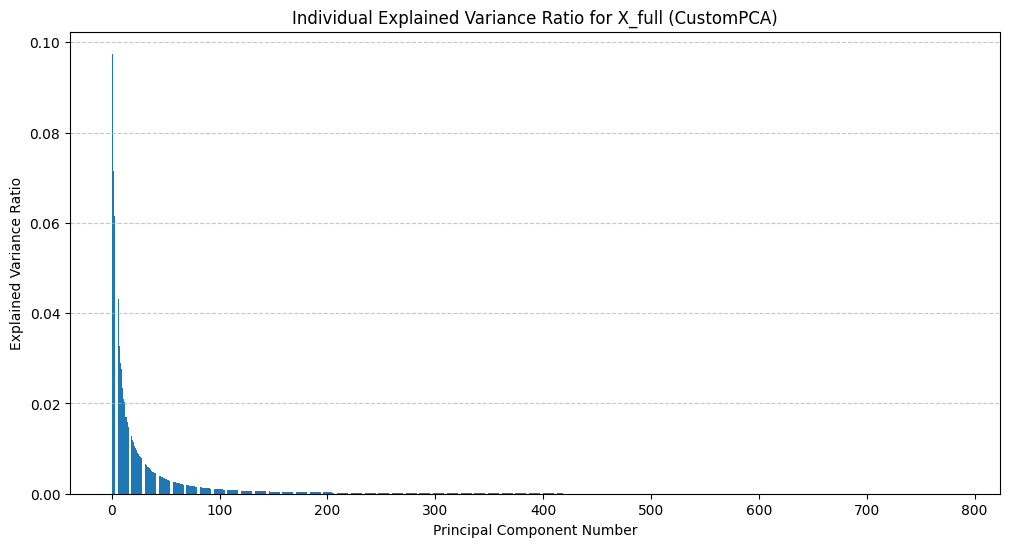

In [104]:
import matplotlib.pyplot as plt

# Plotting individual explained variance ratios
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(custom_pca_full.explained_variance_ratio_) + 1), custom_pca_full.explained_variance_ratio_)
plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance Ratio for X_full (CustomPCA)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Reasoning**:
I need to calculate the cumulative explained variance for the first two principal components from the `custom_pca_full.explained_variance_ratio_` and then print this value, as per the subtask instructions.



In [105]:
cumulative_explained_variance_top2 = np.sum(custom_pca_full.explained_variance_ratio_[:2])
print(f"Cumulative explained variance captured by the first two principal components: {cumulative_explained_variance_top2:.4f}")

Cumulative explained variance captured by the first two principal components: 0.1690


**Reasoning**:
To prepare for plotting the 2D projection, I need to project `X_full` onto its first two principal components. This requires creating a new `CustomPCA` instance with `n_components=2`, fitting it to `X_full`, and then transforming `X_full` using this fitted PCA model. Additionally, I need to concatenate `y_train` and `y_test` to create combined labels for color-coding the scatter plot.



In [106]:
n_components_plot = 2

# Instantiate CustomPCA for 2 components
custom_pca_2d = CustomPCA(n_components=n_components_plot)

# Fit and transform X_full to get the 2D projection
X_projected_2d = custom_pca_2d.fit_transform(X_full)

# Combine y_train and y_test for color-coding the plot
y_full = np.concatenate((y_train, y_test), axis=0)

print("Shape of X_projected_2d:", X_projected_2d.shape)
print("Shape of y_full:", y_full.shape)

Shape of X_projected_2d: (70000, 2)
Shape of y_full: (70000,)


**Reasoning**:
Now that the data has been projected onto two principal components and the labels have been combined, I will create a 2D scatter plot. The plot will show the projected data, color-coded by the digit labels, to visualize the separation of different digits in the reduced dimension space, as specified in the main task.



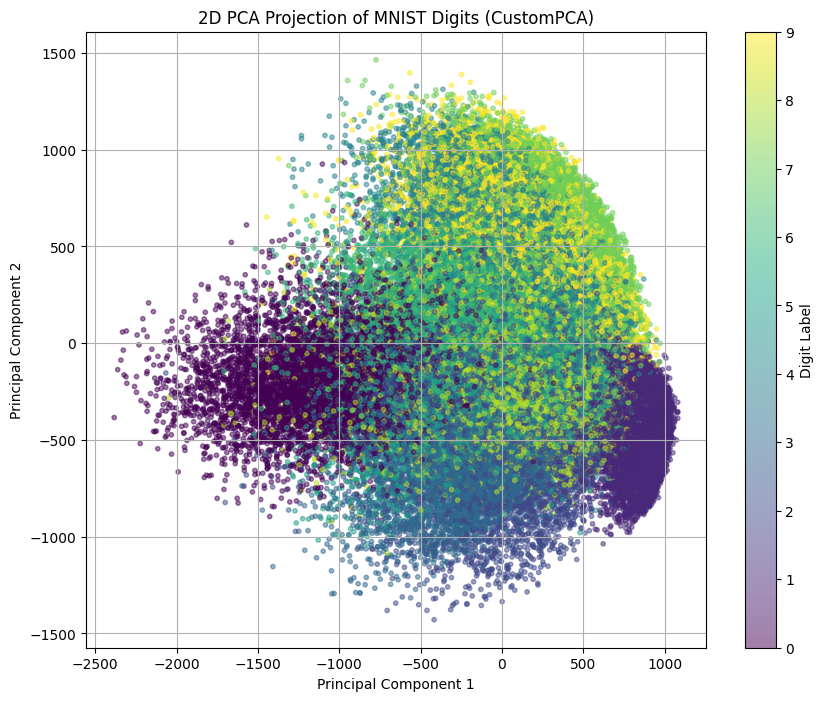

In [107]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_projected_2d[:, 0], X_projected_2d[:, 1], c=y_full, cmap='viridis', s=10, alpha=0.5)
plt.colorbar(scatter, ticks=range(10), label='Digit Label')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection of MNIST Digits (CustomPCA)')
plt.grid(True)
plt.show()

In [108]:
# Calculate the total explained variance as a percentage
total_explained_variance_percentage = np.sum(custom_pca_full.explained_variance_ratio_) * 100
print(f"Total explained variance for X_full (all components): {total_explained_variance_percentage:.2f}%")

# Reiterate the cumulative explained variance for the first two components
print(f"Cumulative explained variance captured by the first two principal components: {cumulative_explained_variance_top2*100:.2f}%")

Total explained variance for X_full (all components): 100.00%
Cumulative explained variance captured by the first two principal components: 16.90%


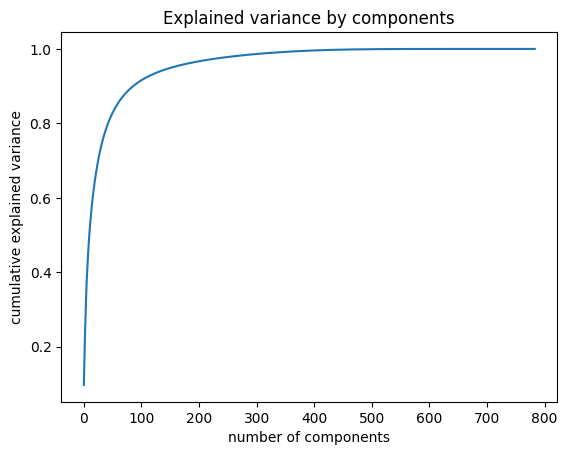

In [109]:
plt.plot(np.cumsum(custom_pca_full.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.title('Explained variance by components')
plt.show()

## Summary of PCA Analysis on MNIST Dataset

### CustomPCA Implementation and Application
1.  **CustomPCA Enhancement**: The `CustomPCA` class was successfully modified to calculate and store `explained_variance_ratio_`, allowing for a direct comparison with `sklearn.decomposition.PCA`.
2.  **Iris Dataset Comparison**: Initial tests on the Iris dataset confirmed that our `CustomPCA` implementation produced `explained_variance_ratio_` identical to scikit-learn's PCA, demonstrating its correctness. Cumulative explained variance plots also showed perfect alignment.

### PCA on Flattened MNIST Images (`X_full`)
1.  **Full Component Analysis**: `CustomPCA` was applied to the `X_full` dataset (70,000 MNIST images flattened to 784 features) with `n_components=784`. This allowed for the calculation of the explained variance ratio for every principal component.
2.  **Individual Explained Variance**: The bar chart of individual explained variance ratios clearly showed that a large portion of the variance is captured by the first few principal components, with a rapid decrease thereafter. This indicates the high redundancy in the original 784-dimensional pixel space of MNIST images.
3.  **Cumulative Explained Variance (First 2 Components)**: The first two principal components together captured a cumulative explained variance of approximately **0.1690 (16.90%)**. While this might seem low in isolation, it's a significant reduction from 784 dimensions to 2, and often still provides valuable visualization of data structure.
4.  **2D Projection Visualization**: A 2D scatter plot of the MNIST digits projected onto the first two principal components was generated. This plot visually demonstrated:
    *   **Clustering**: Different digit classes tend to form distinct clusters in the 2D space, although with some overlap, especially for digits that are visually similar (e.g., 4 and 9, or 7 and 1).
    *   **Separability**: Some digits, like '0' and '1', appear to be relatively well-separated, while others are more intertwined, indicating the inherent complexity of the dataset even after PCA.
    *   **Information Preservation**: Despite only retaining about 17% of the total variance, the first two principal components manage to preserve enough structural information to reveal general patterns and separability trends among the digits.

### Conclusion
This PCA analysis, performed with our custom implementation, effectively reduced the dimensionality of the MNIST dataset while retaining crucial information about its structure. The visualizations provide insights into the separability of different digit classes in a lower-dimensional space, which is valuable for understanding the dataset and for potential downstream tasks like classification or further unsupervised learning.

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE


In [111]:
from sklearn.datasets import load_digits
digits=load_digits()
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [112]:
print(digits['data'].shape)
print(digits['target'].shape)

(1797, 64)
(1797,)


In [113]:
tsne=TSNE(n_components=2,random_state=42)

In [114]:
x_transformed=tsne.fit_transform(digits['data'])

In [115]:
tsne_df=pd.DataFrame(np.column_stack((x_transformed,digits['target'])),columns=['x','y','Targets'])
tsne_df.loc[:, 'Targets']=tsne_df.Targets.astype(int)

In [116]:
tsne_df.head(10)

,x,y,Targets
0,-3.024210,-53.885437,0.0
1,10.376657,11.264841,1.0
2,-13.521493,18.822712,2.0
3,-35.524765,-6.349295,3.0
4,40.953392,7.328811,4.0
5,-27.095041,-15.059107,5.0
6,34.530472,-14.780560,6.0
7,2.225859,42.040230,7.0
8,-14.532291,5.938167,8.0
9,-20.070793,-15.172290,9.0


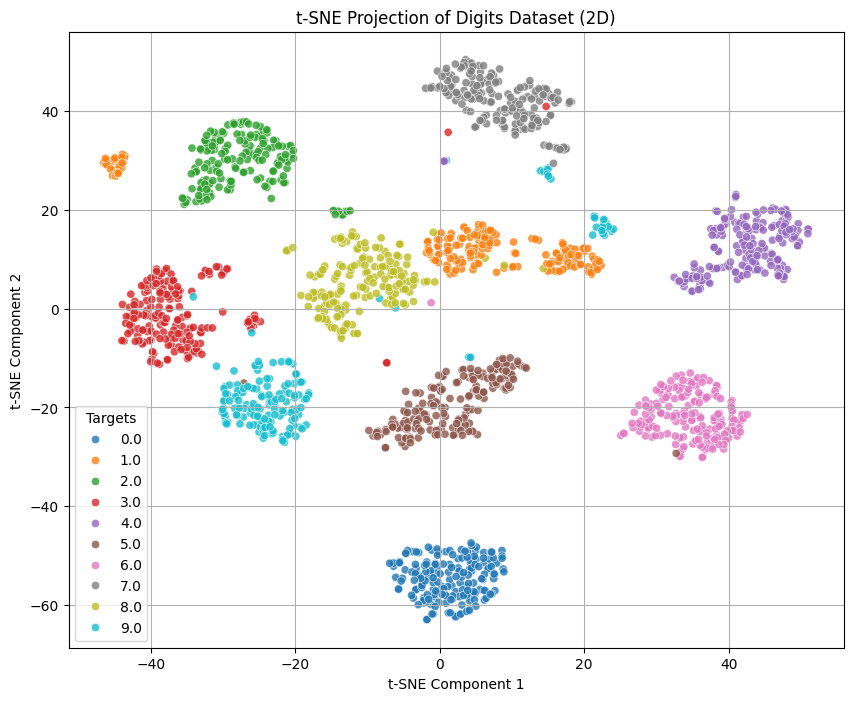

In [118]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='x',
    y='y',
    hue='Targets',
    palette=sns.color_palette('tab10', 10),
    data=tsne_df,
    legend='full',
    alpha=0.8
)
plt.title('t-SNE Projection of Digits Dataset (2D)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()